• Preparation:
• Import python libraries necessary for the analysis.
• Import the CSV file NSMES1988.csv file as a dataframe (df) and assign the first column as the index
• Convert age and income to their proper values based on the data dictionary 

In [3]:
import numpy as np
import scipy as sp
import pandas as pd


In [89]:
df=pd.read_csv('C:\\github\\AIML_PySpark\\Purdue_Post_Graduate_Program_AIML\\2. Applied Data Science with Python\\NSMES1988.csv', index_col=0)
df['income']=df['income']*10000
df['age']=df['age']*10
df

,visits,nvisits,ovisits,novisits,emergency,hospital,health,chronic,adl,region,age,afam,gender,married,school,income,employed,insurance,medicaid
1,5,0,0,0,0,1,average,2,normal,other,69.0,yes,male,yes,6,28810.00,yes,yes,no
2,1,0,2,0,2,0,average,2,normal,other,74.0,no,female,yes,10,27478.00,no,yes,no
3,13,0,0,0,3,3,poor,4,limited,other,66.0,yes,female,no,10,6532.00,no,no,yes
4,16,0,5,0,1,1,poor,2,limited,other,76.0,no,male,yes,3,6588.00,no,yes,no
5,3,0,0,0,0,0,average,2,limited,other,79.0,no,female,yes,6,6588.00,no,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,11,0,0,0,0,0,average,0,normal,other,84.0,no,female,yes,8,22497.00,no,yes,no
4403,12,0,0,0,0,0,average,2,normal,other,78.0,no,female,no,11,58132.00,no,yes,no
4404,10,0,20,0,1,1,average,5,normal,other,73.0,no,male,yes,12,38779.16,no,yes,no
4405,16,1,0,0,0,0,average,0,normal,other,66.0,no,female,yes,12,38779.16,no,yes,no


In [22]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4406 entries, 1 to 4406
Data columns (total 19 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   visits     4406 non-null   int64  
 1   nvisits    4406 non-null   int64  
 2   ovisits    4406 non-null   int64  
 3   novisits   4406 non-null   int64  
 4   emergency  4406 non-null   int64  
 5   hospital   4406 non-null   int64  
 6   health     4406 non-null   object 
 7   chronic    4406 non-null   int64  
 8   adl        4406 non-null   object 
 9   region     4406 non-null   object 
 10  age        4406 non-null   float64
 11  afam       4406 non-null   object 
 12  gender     4406 non-null   object 
 13  married    4406 non-null   object 
 14  school     4406 non-null   int64  
 15  income     4406 non-null   float64
 16  employed   4406 non-null   object 
 17  insurance  4406 non-null   object 
 18  medicaid   4406 non-null   object 
dtypes: float64(2), int64(8), object(9)
memory usage: 688.

In [27]:
int_cols = df.select_dtypes(exclude='object').columns #include='numeric'
int_cols

Index(['visits', 'nvisits', 'ovisits', 'novisits', 'emergency', 'hospital',
       'chronic', 'age', 'school', 'income'],
      dtype='object')

In [28]:
cat_cols = df.select_dtypes(include='object').columns #include='numeric'
cat_cols

Index(['health', 'adl', 'region', 'afam', 'gender', 'married', 'employed',
       'insurance', 'medicaid'],
      dtype='object')

In [36]:
df.mean(numeric_only=True)

visits           5.774399
nvisits          1.618021
ovisits          0.750794
novisits         0.536087
emergency        0.263504
hospital         0.295960
chronic          1.541988
age             74.024058
school          10.290286
income       25271.320468
dtype: float64

In [38]:
df.std(numeric_only=True)

visits           6.759225
nvisits          5.317056
ovisits          3.652759
novisits         3.879506
emergency        0.703659
hospital         0.746398
chronic          1.349632
age              6.334050
school           3.738736
income       29246.476178
dtype: float64

In [37]:
df.describe(include=np.number)

,visits,nvisits,ovisits,novisits,emergency,hospital,chronic,age,school,income
count,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000,4406.000000
mean,5.774399,1.618021,0.750794,0.536087,0.263504,0.295960,1.541988,74.024058,10.290286,25271.320468
std,6.759225,5.317056,3.652759,3.879506,0.703659,0.746398,1.349632,6.334050,3.738736,29246.476178
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,66.000000,0.000000,-10125.000000
25%,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,69.000000,8.000000,9121.500000
50%,4.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,73.000000,11.000000,16981.500000
75%,8.000000,1.000000,0.000000,0.000000,0.000000,0.000000,2.000000,78.000000,12.000000,31728.500000
max,89.000000,104.000000,141.000000,155.000000,12.000000,8.000000,8.000000,109.000000,18.000000,548351.000000


In [54]:
df[['employed', 'hospital']].groupby('employed').sum()

,hospital
employed,
no,1201
yes,103


In [ ]:
# ** Build a pivot table that shows the mean of all numerical measures with health column as an index**
df.pivot_table(index=['health'], aggfunc=['mean'])

SyntaxError: invalid character '•' (U+2022) (2539783184.py, line 1)

• What is the average number of emergency room visits for each region and gender combination? 


In [64]:
# df[['region','gender','emergency']].groupby('emergency').mean()
df.groupby(['region', 'gender'])['emergency'].mean()

region     gender
midwest    female    0.230435
           male      0.241970
northeast  female    0.239130
           male      0.265861
other      female    0.289583
           male      0.273700
west       female    0.317797
           male      0.223926
Name: emergency, dtype: float64

Get the number of individuals covered by Medicaid and derive the ratio of patients with hospital stays

In [91]:
Medicare_Yes = df['medicaid'].value_counts().get('yes',0)
Medicare_Yes

np.int64(402)

In [101]:
med_yes = df['medicaid'].value_counts().get('yes',0)
ratio = (med_yes / df['hospital'].sum())*100
round(ratio,2)


np.float64(30.83)

Working with Pandas and Data Visualization

In [102]:
import plotly.express as px
import plotly.graph_objects as go

In [108]:
import seaborn as sns
import matplotlib.pyplot as plt

• Build a histogram for every numerical column using subplots and report the columns that have a lot of outliers


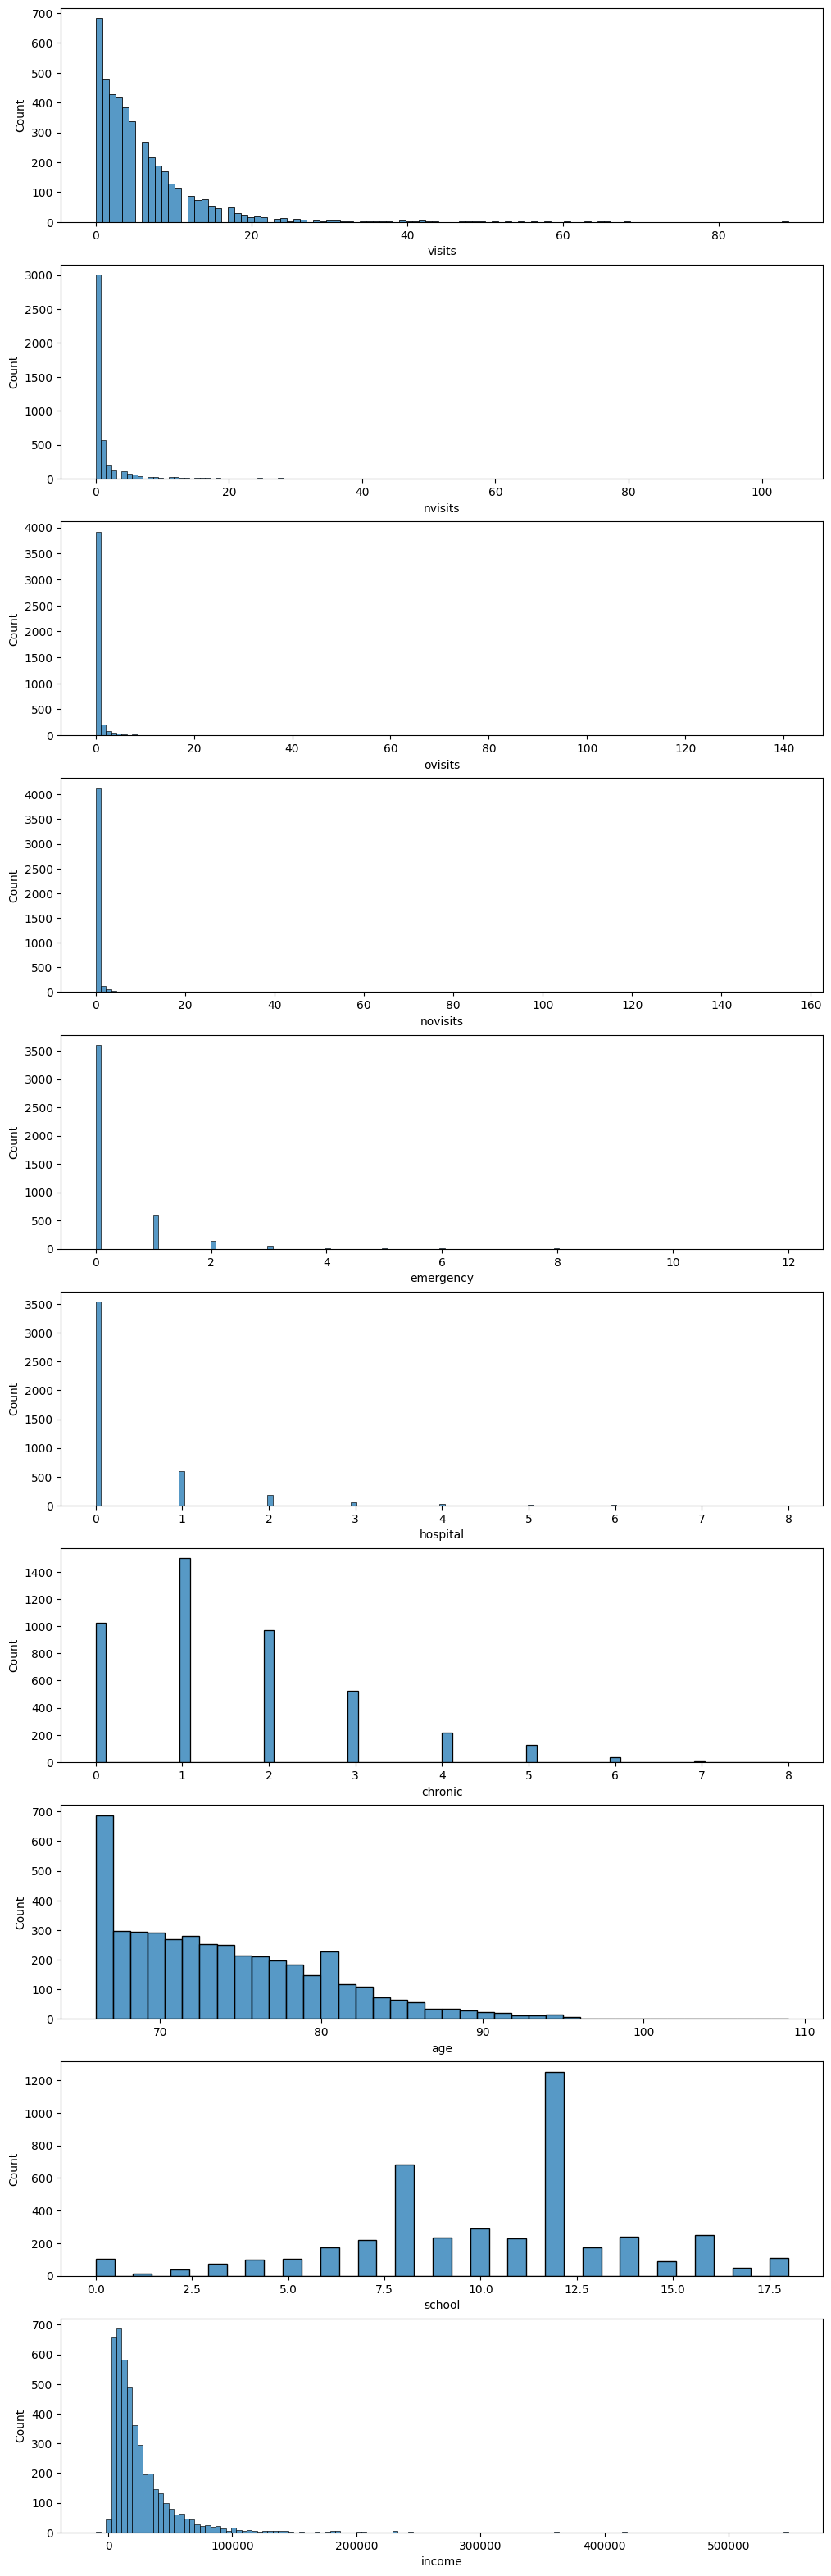

In [116]:
fig, axes = plt.subplots(nrows=10,ncols=1, figsize=(12,40))
my_plot_cols=['visits','nvisits', 'ovisits', 'novisits', 'emergency', 'hospital', 'chronic', 'age', 'school', 'income']
axes=axes.flatten()
for idx,col in enumerate(my_plot_cols):
    sns.histplot(data=df,x=col,ax=axes[idx])

No outliers are seen in the subplots 


<Axes: xlabel='visits'>

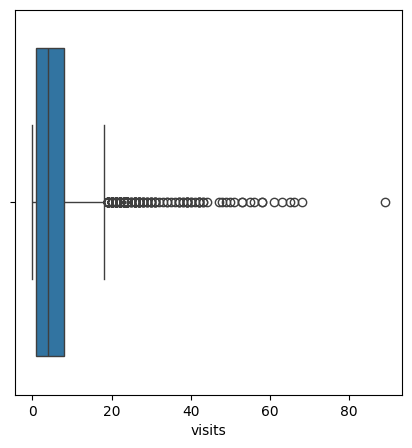

In [125]:
plt.figure(figsize=(5,5))
sns.boxplot(x=df['visits'])

For the hospital column perform box and whisker analysis based on the following categories:
• Gender
• Marital Status
• Employment Status

<Axes: xlabel='visits'>

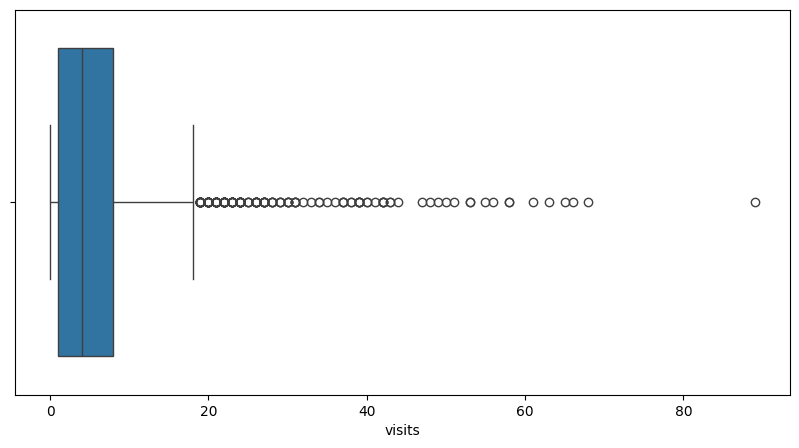

In [142]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df['visits'])

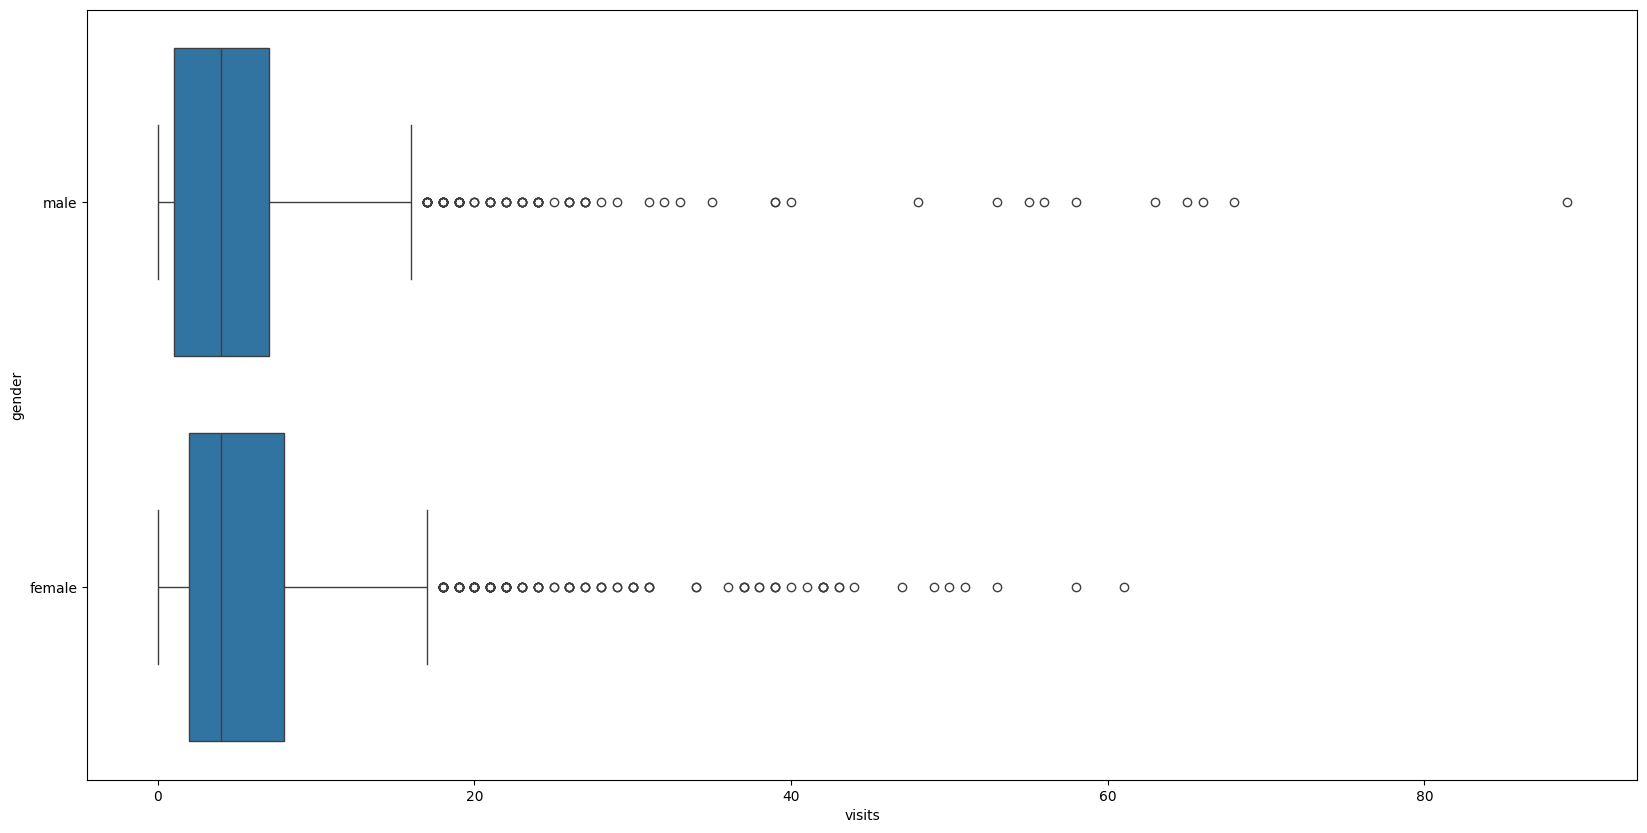

In [147]:
plt.figure(figsize=(20,10))
ax=sns.boxplot(data=df, x='visits',y='gender')

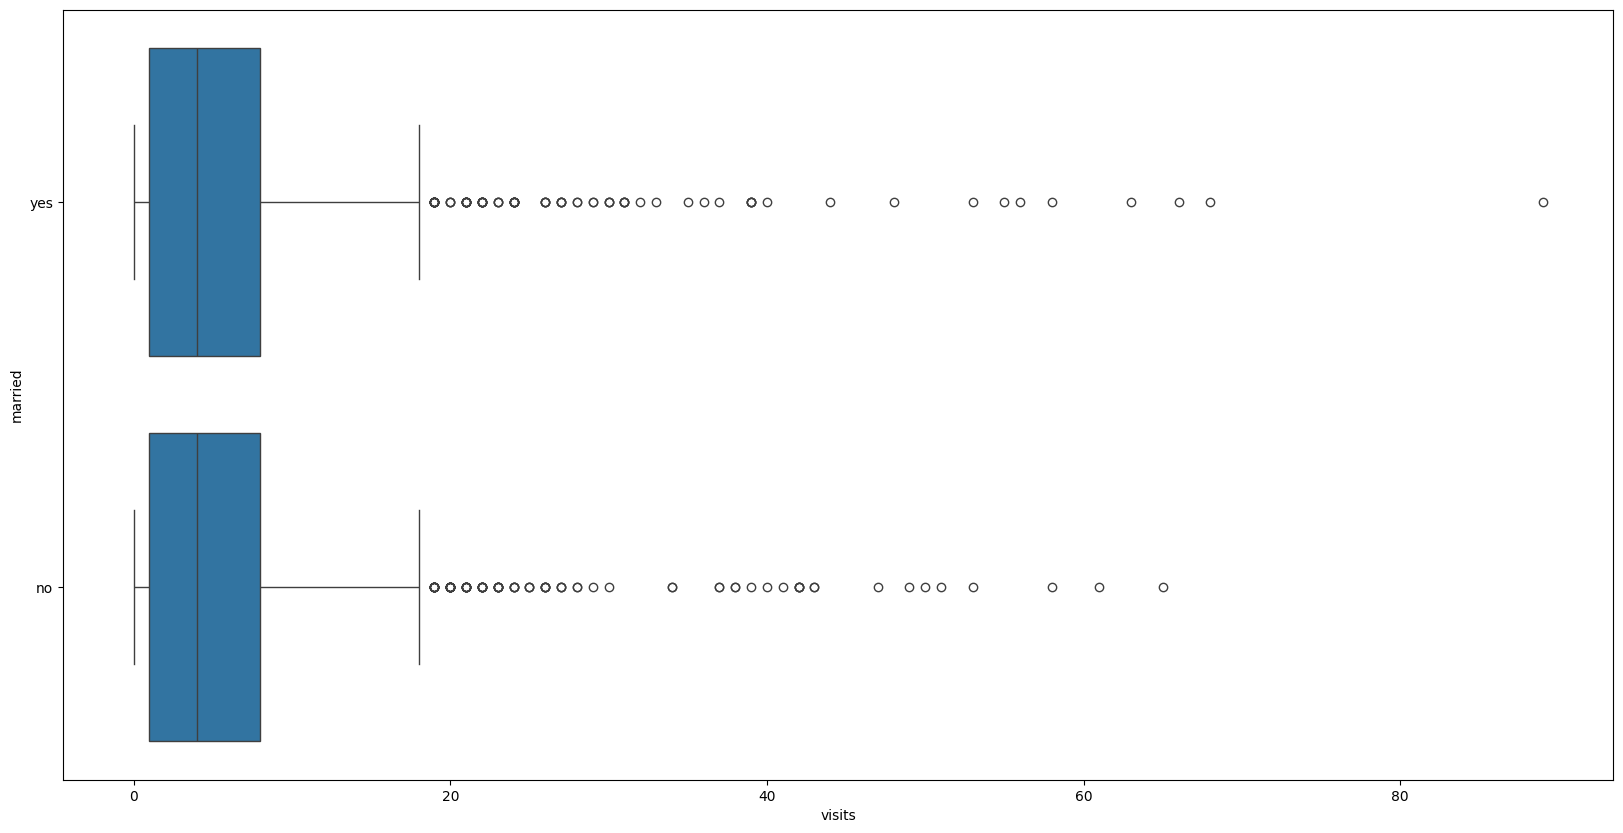

In [148]:
plt.figure(figsize=(20,10))
ax=sns.boxplot(data=df, x='visits',y='married')

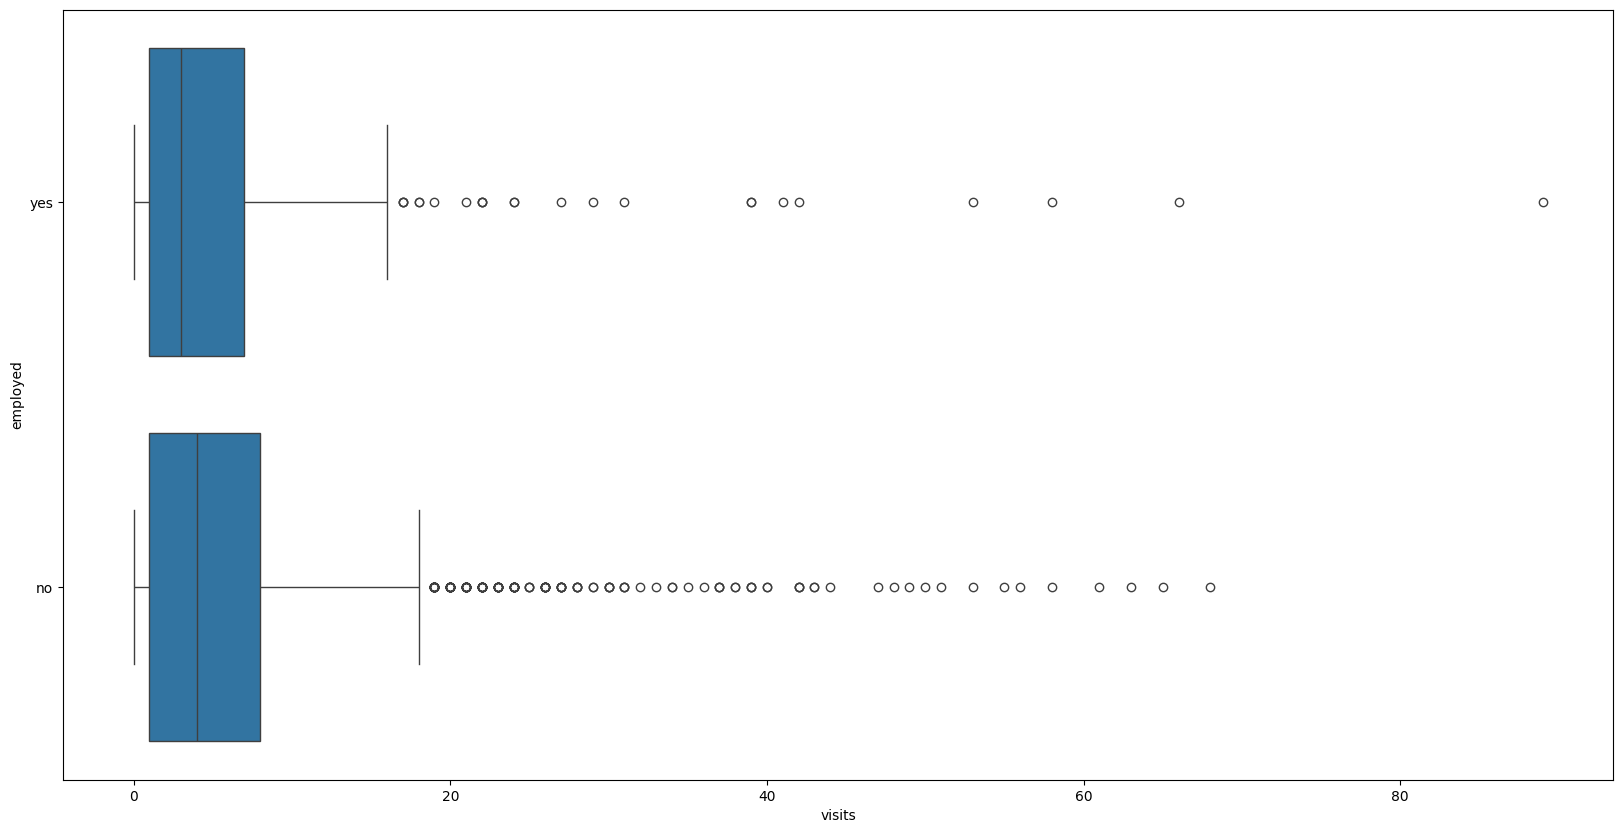

In [149]:
plt.figure(figsize=(20,10))
ax=sns.boxplot(data=df, x='visits',y='employed')

Generate a plot to view the number of individuals within each age group, separated by gender

In [150]:
df


,visits,nvisits,ovisits,novisits,emergency,hospital,health,chronic,adl,region,age,afam,gender,married,school,income,employed,insurance,medicaid
1,5,0,0,0,0,1,average,2,normal,other,69.0,yes,male,yes,6,28810.00,yes,yes,no
2,1,0,2,0,2,0,average,2,normal,other,74.0,no,female,yes,10,27478.00,no,yes,no
3,13,0,0,0,3,3,poor,4,limited,other,66.0,yes,female,no,10,6532.00,no,no,yes
4,16,0,5,0,1,1,poor,2,limited,other,76.0,no,male,yes,3,6588.00,no,yes,no
5,3,0,0,0,0,0,average,2,limited,other,79.0,no,female,yes,6,6588.00,no,yes,no
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,11,0,0,0,0,0,average,0,normal,other,84.0,no,female,yes,8,22497.00,no,yes,no
4403,12,0,0,0,0,0,average,2,normal,other,78.0,no,female,no,11,58132.00,no,yes,no
4404,10,0,20,0,1,1,average,5,normal,other,73.0,no,male,yes,12,38779.16,no,yes,no
4405,16,1,0,0,0,0,average,0,normal,other,66.0,no,female,yes,12,38779.16,no,yes,no


In [153]:
df['agegroup']=df['age']//10*10
df

,visits,nvisits,ovisits,novisits,emergency,hospital,health,chronic,adl,region,age,afam,gender,married,school,income,employed,insurance,medicaid,agegroup
1,5,0,0,0,0,1,average,2,normal,other,69.0,yes,male,yes,6,28810.00,yes,yes,no,60.0
2,1,0,2,0,2,0,average,2,normal,other,74.0,no,female,yes,10,27478.00,no,yes,no,70.0
3,13,0,0,0,3,3,poor,4,limited,other,66.0,yes,female,no,10,6532.00,no,no,yes,60.0
4,16,0,5,0,1,1,poor,2,limited,other,76.0,no,male,yes,3,6588.00,no,yes,no,70.0
5,3,0,0,0,0,0,average,2,limited,other,79.0,no,female,yes,6,6588.00,no,yes,no,70.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4402,11,0,0,0,0,0,average,0,normal,other,84.0,no,female,yes,8,22497.00,no,yes,no,80.0
4403,12,0,0,0,0,0,average,2,normal,other,78.0,no,female,no,11,58132.00,no,yes,no,70.0
4404,10,0,20,0,1,1,average,5,normal,other,73.0,no,male,yes,12,38779.16,no,yes,no,70.0
4405,16,1,0,0,0,0,average,0,normal,other,66.0,no,female,yes,12,38779.16,no,yes,no,60.0


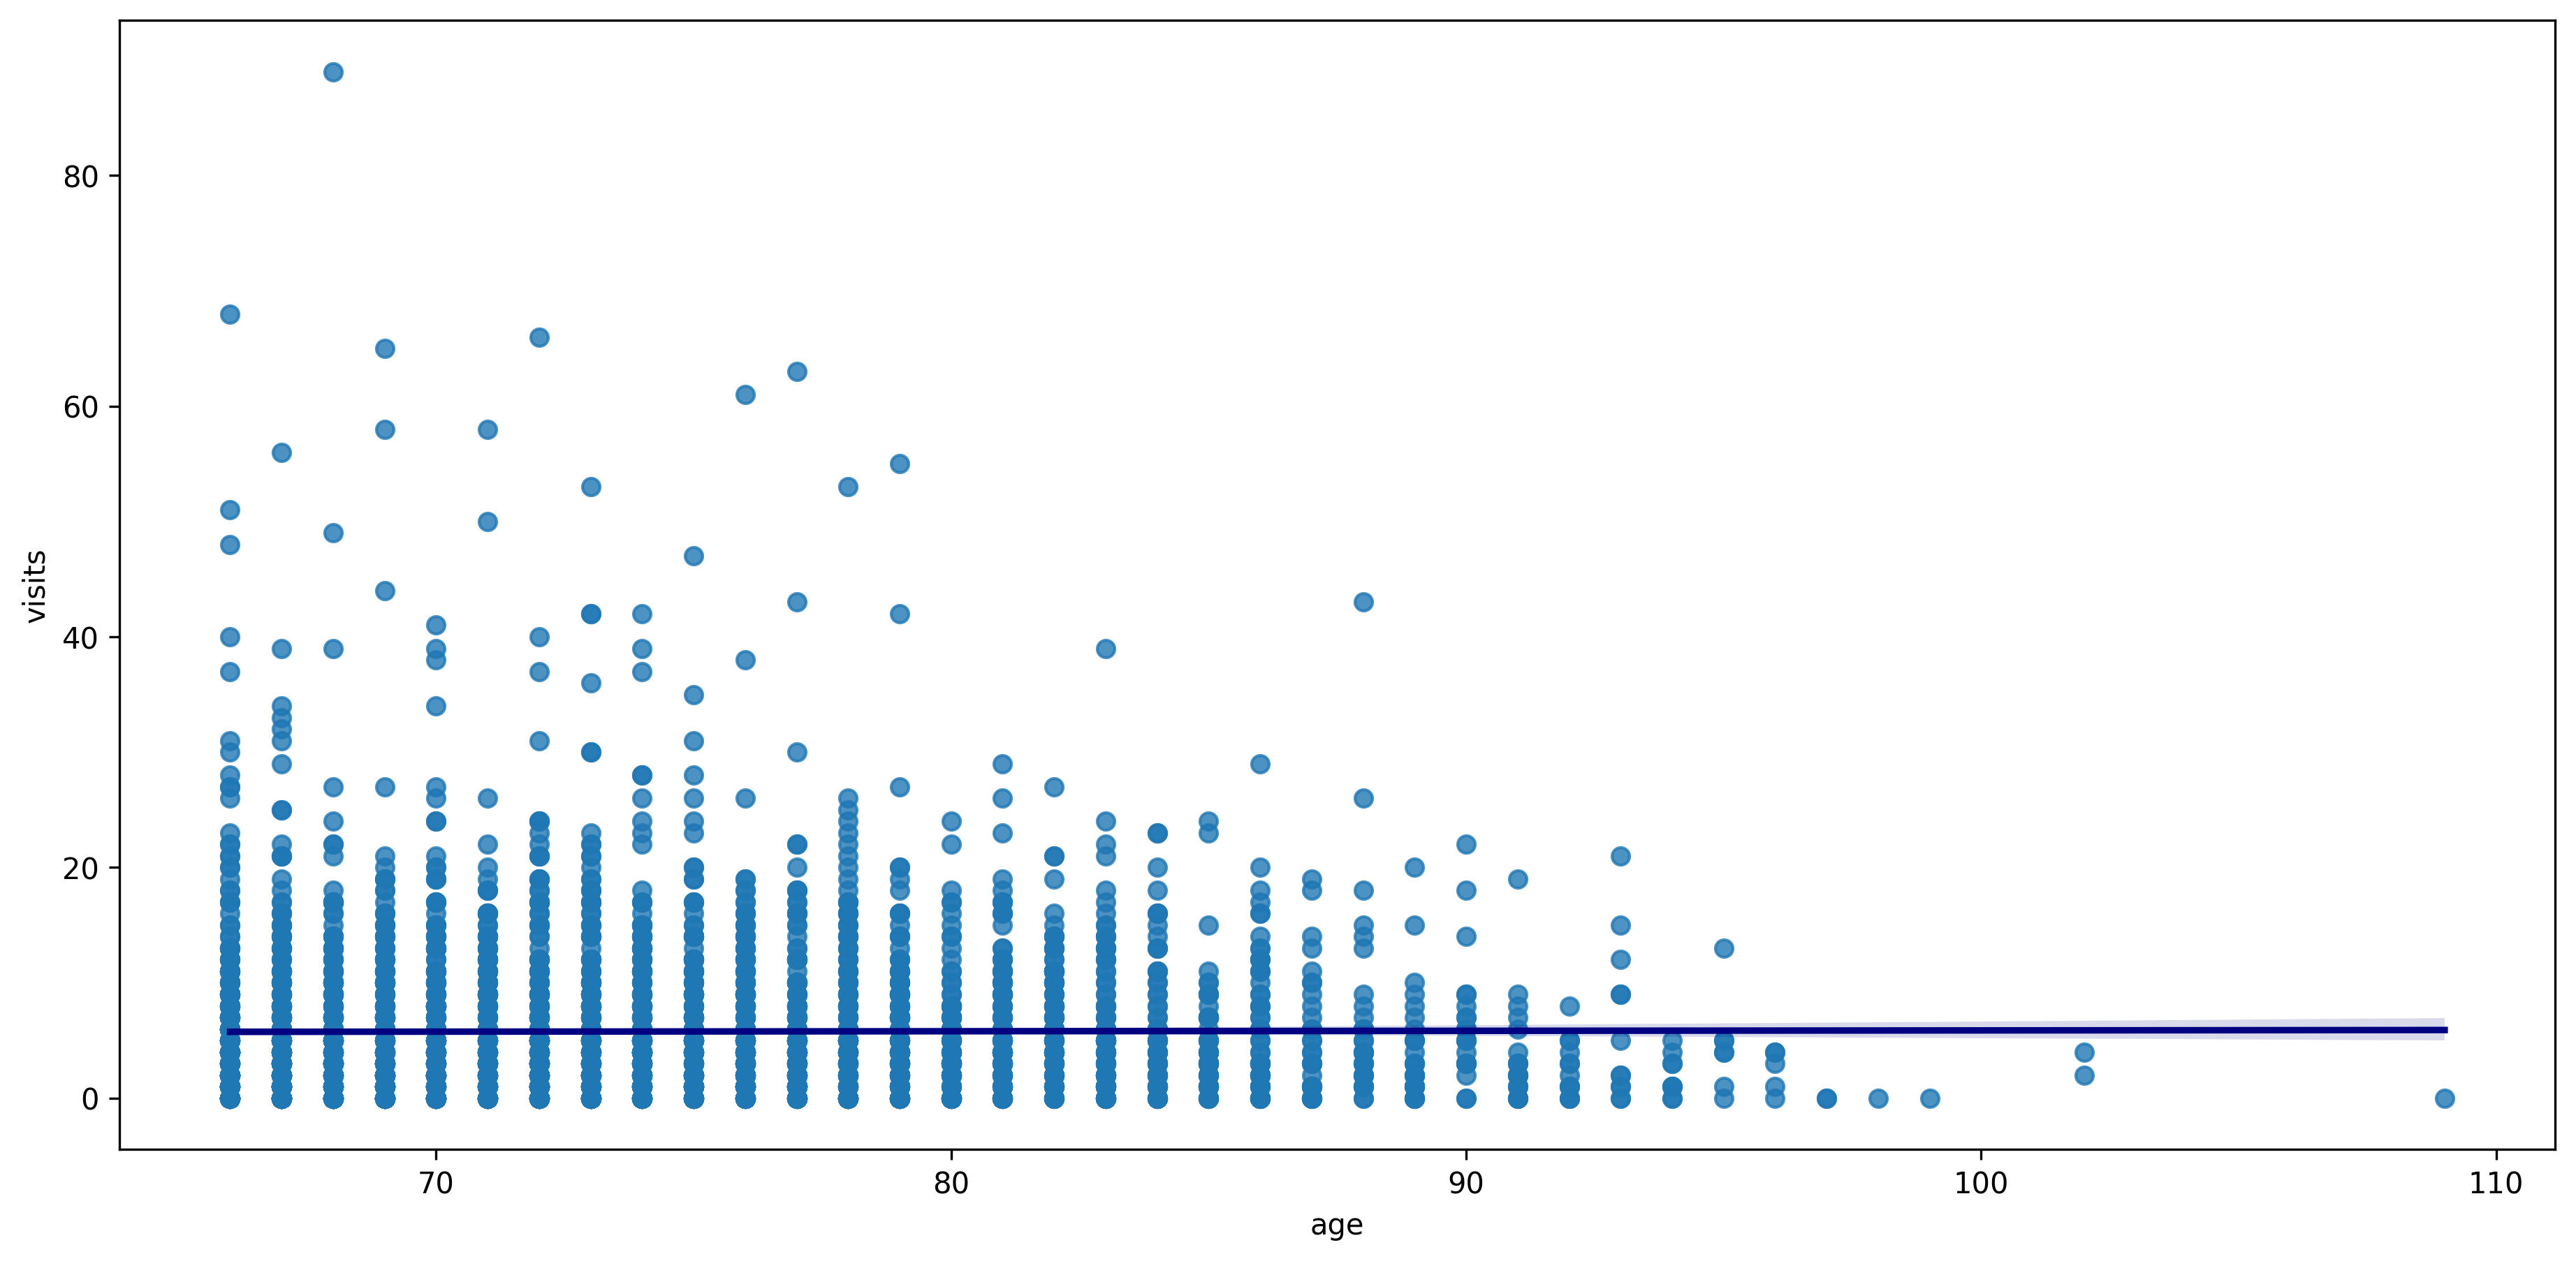

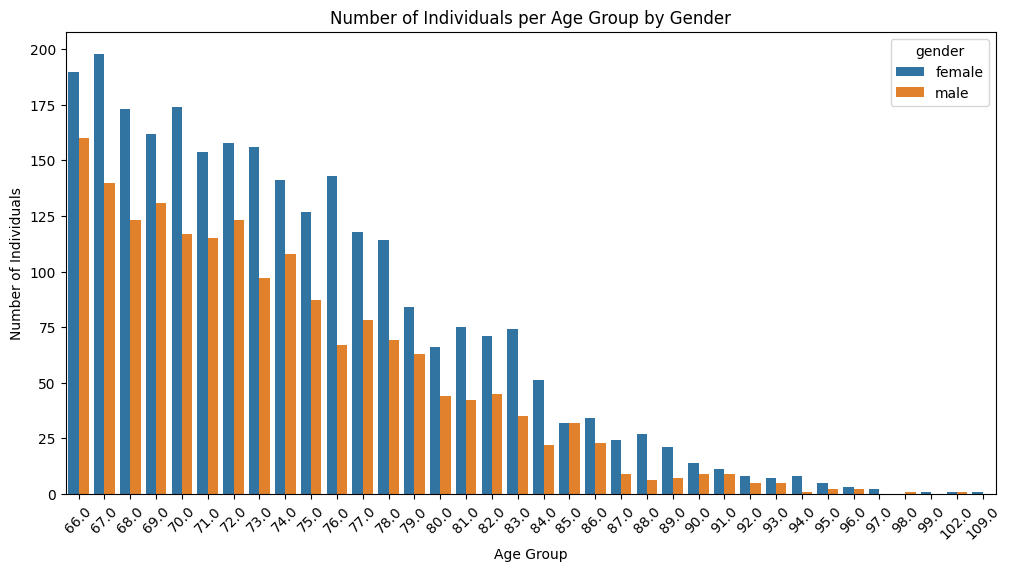

In [156]:
plt.figure(figsize=(15,7),dpi=300)
sns.regplot(x=df['age'],y=df['visits'],line_kws={'color':'navy'})

plt.figure(figsize=(12,6))
sns.countplot(data=df, x='age', hue='gender')
plt.title("Number of Individuals per Age Group by Gender")
plt.xlabel("Age Group")
plt.ylabel("Number of Individuals")
plt.xticks(rotation=45)
plt.show()